In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

sys.path.append("src")
from entropy_pruning import (
    AttentionForecaster,
    UNILoRAClassifier,
    build_attention_cache,
    build_loaders,
    set_seed,
    train_forecaster,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/vcivale/miniconda3/envs/entropy_pruning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [4]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import h5py
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

CFG = dict(
    data_dir="/raid/DATASETS/NCT-CRC-HE/",
    img_size=224,
    batch_size=512,
    num_workers=4,
    seed=42,
    layer_source=2,
    layer_target=23,
    epochs=30,
    lr=1e-4,
    weight_decay=0.05,
    # fixed architecture (best from architecture ablation)
    hidden=256,
    n_heads=4,
    n_layers=2,
    dropout=0.1,
)


# --- Loss functions ---

# ── Distribution-aware (ours) ─────────────────────────────────────────────────
def loss_kl_only(pred, target):
    """KL divergence — distribution-aware, no extra hyper-parameters."""
    return F.kl_div((pred + 1e-8).log(), target + 1e-8, reduction="batchmean")


def loss_jsd(pred, target):
    """Jensen-Shannon divergence — symmetric KL variant."""
    m = 0.5 * (pred + target)
    kl_pm = F.kl_div((pred + 1e-8).log(), m + 1e-8, reduction="batchmean")
    kl_tm = F.kl_div((target + 1e-8).log(), m + 1e-8, reduction="batchmean")
    return 0.5 * (kl_pm + kl_tm)


def loss_reverse_kl(pred, target):
    """Reverse KL: KL(target || pred) — mode-seeking, collapses on peaks."""
    return F.kl_div((target + 1e-8).log(), pred + 1e-8, reduction="batchmean")


# ── Geometric / direction-based ───────────────────────────────────────────────
def loss_cosine(pred, target):
    """1 - cosine similarity — direction only, ignores magnitude."""
    return 1 - F.cosine_similarity(pred, target, dim=-1).mean()


def loss_pearson(pred, target):
    """1 - Pearson r — linear correlation, sensitive to outliers."""
    pred_c = pred - pred.mean(dim=-1, keepdim=True)
    tgt_c  = target - target.mean(dim=-1, keepdim=True)
    num    = (pred_c * tgt_c).sum(dim=-1)
    den    = pred_c.norm(dim=-1) * tgt_c.norm(dim=-1) + 1e-8
    return 1 - (num / den).mean()


# ── Element-wise regression ───────────────────────────────────────────────────
def loss_mse_only(pred, target):
    """MSE — element-wise L2, ignores distributional structure."""
    return F.mse_loss(pred, target)


def loss_l1(pred, target):
    """L1 / MAE — element-wise absolute error, same family as MSE."""
    return F.l1_loss(pred, target)


def loss_huber(pred, target):
    """Huber (smooth L1) — robust regression, no distributional awareness."""
    return F.smooth_l1_loss(pred, target)


LOSS_CONFIGS = [
    # Distribution-aware
    ("KL Divergence\n(ours)",   loss_kl_only),
    ("JSD",                      loss_jsd),
    ("Reverse KL",               loss_reverse_kl),
    # Geometric
    ("Cosine",                   loss_cosine),
    ("Pearson",                  loss_pearson),
    # Element-wise regression
    ("MSE",                      loss_mse_only),
    ("L1 / MAE",                 loss_l1),
    ("Huber",                    loss_huber),
]

set_seed(CFG["seed"])
dataset_name = Path(CFG["data_dir"]).name
classifier_ckpt = Path(f"/raid/DATASETS/checkpoints-Attention-Pruning/{dataset_name}/uni_finetuned/best_model.pt")
cache_path = Path(f"/raid/DATASETS/NCT-CRC-HE/data_cache/{dataset_name}_forecaster_dataset.h5")
forecaster_dir = Path(f"/raid/DATASETS/checkpoints-Attention-Pruning/{dataset_name}/loss_ablation")
forecaster_dir.mkdir(parents=True, exist_ok=True)

print(f"Loss functions: {len(LOSS_CONFIGS)}")
for name, _ in LOSS_CONFIGS:
    print(f"  {name.replace(chr(10), ' ')}")

Loss functions: 8
  KL Divergence (ours)
  JSD
  Reverse KL
  Cosine
  Pearson
  MSE
  L1 / MAE
  Huber


In [5]:
loaders = build_loaders(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    num_workers=CFG["num_workers"],
    drop_last_train=False,
)

model = UNILoRAClassifier(loaders.n_classes).to(device)
model.load_state_dict(torch.load(classifier_ckpt, map_location=device), strict=False)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

if not cache_path.exists():
    build_attention_cache(
        model=model,
        loaders={"train": loaders.train_loader, "val": loaders.val_loader, "test": loaders.test_loader},
        device=device,
        source_layers=[CFG["layer_source"]],
        target_layers=[CFG["layer_target"]],
        save_path=cache_path,
    )
print("Cache:", cache_path)

del model
torch.cuda.empty_cache()

Cache: /raid/DATASETS/NCT-CRC-HE/data_cache/NCT-CRC-HE_forecaster_dataset.h5


In [6]:
# FIX #2: carica tutto il dataset in RAM in float16 (43 GB totali, 217 GB disponibili)
# I tensori restano fp16 fino alla GPU, dove vengono castati — nessun I/O su disco durante il training
def load_split_to_tensors(h5_path, split, layer_source, layer_target):
    with h5py.File(h5_path, "r") as f:
        if split not in f:
            split = "validation" if split == "val" else "val"
        grp = f[split]
        emb    = torch.from_numpy(grp[f"emb_layer{layer_source}"][:])   # già float16
        target = torch.from_numpy(grp[f"attn_layer{layer_target}"][:])  # già float16
        labels = torch.from_numpy(grp["labels"][:]).long()
    return TensorDataset(emb, target, labels)

print("Caricamento dataset in RAM (float16)...")
train_ds_mem = load_split_to_tensors(cache_path, "train", CFG["layer_source"], CFG["layer_target"])
val_ds_mem   = load_split_to_tensors(cache_path, "val",   CFG["layer_source"], CFG["layer_target"])
test_ds_mem  = load_split_to_tensors(cache_path, "test",  CFG["layer_source"], CFG["layer_target"])

emb_bytes = train_ds_mem.tensors[0].nbytes + val_ds_mem.tensors[0].nbytes + test_ds_mem.tensors[0].nbytes
print(f"  train: {len(train_ds_mem):,}  val: {len(val_ds_mem):,}  test: {len(test_ds_mem):,}")
print(f"  RAM usata: {emb_bytes/1e9:.1f} GB")

loader_kw = dict(batch_size=CFG["batch_size"], num_workers=CFG["num_workers"],
                 pin_memory=True, persistent_workers=True)
train_loader_mem = DataLoader(train_ds_mem, shuffle=True,  **loader_kw)
val_loader_mem   = DataLoader(val_ds_mem,   shuffle=False, **loader_kw)
test_loader_mem  = DataLoader(test_ds_mem,  shuffle=False, **loader_kw)

Caricamento dataset in RAM (float16)...
  train: 90,000  val: 10,000  test: 7,180
  RAM usata: 43.0 GB


In [7]:
import re
import torch.nn.functional as F
from tqdm.auto import tqdm

def spearman_matrix(pred_np, tgt_np):
    """Spearman rho vettorizzato su tutto il batch — evita loop Python."""
    def rankdata_2d(x):
        idx = np.argsort(x, axis=1)
        ranks = np.empty_like(idx, dtype=np.float32)
        np.put_along_axis(ranks, idx, np.arange(1, x.shape[1]+1, dtype=np.float32)[None], axis=1)
        return ranks
    rp, rt = rankdata_2d(pred_np), rankdata_2d(tgt_np)
    n = pred_np.shape[1]
    return 1 - 6 * ((rp - rt)**2).sum(axis=1) / (n * (n**2 - 1))


def sanitize_tag(name):
    """Turn a loss name into a safe filename component."""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', name.replace('\n', '_')).strip('_')


def train_forecaster_fast(forecaster_model, loss_fn, save_path, device, cfg,
                          train_loader, val_loader, test_loader):
    forecaster = forecaster_model.to(device)
    opt = torch.optim.AdamW(forecaster.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])

    best_val_kl = float("inf")
    best_val_rho = -1.0

    for _ in tqdm(range(cfg["epochs"]), desc="epochs", leave=False):
        # --- train ---
        forecaster.train()
        for emb, target, _ in tqdm(train_loader, leave=False):
            emb    = emb.to(device, non_blocking=True).float()
            target = target.to(device, non_blocking=True).float()
            pred = forecaster(emb)
            loss = loss_fn(pred, target)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(forecaster.parameters(), 1.0)
            opt.step()

        # --- val: un solo sync alla fine ---
        forecaster.eval()
        val_kl_acc = torch.zeros(1, device=device)
        all_pred, all_tgt = [], []
        with torch.no_grad():
            for emb, target, _ in val_loader:
                emb    = emb.to(device, non_blocking=True).float()
                target = target.to(device, non_blocking=True).float()
                pred = forecaster(emb)
                val_kl_acc += F.kl_div((pred + 1e-8).log(), target + 1e-8, reduction="batchmean")
                all_pred.append(pred)
                all_tgt.append(target)

        pred_np = torch.cat(all_pred).cpu().numpy()
        tgt_np  = torch.cat(all_tgt).cpu().numpy()
        val_kl  = (val_kl_acc / len(val_loader)).item()
        val_rho = float(np.nanmean(spearman_matrix(pred_np, tgt_np)))

        if val_kl < best_val_kl:
            best_val_kl  = val_kl
            best_val_rho = val_rho
            torch.save(forecaster.state_dict(), save_path)
        sched.step()

    forecaster.load_state_dict(torch.load(save_path, map_location=device))
    forecaster.eval()
    test_rhos_f, test_rhos_n = [], []
    with torch.no_grad():
        for emb, target, _ in test_loader:
            pred  = forecaster(emb.to(device, non_blocking=True).float()).cpu().numpy()
            tgt   = target.numpy().astype(np.float32)
            norms = emb.float().norm(dim=-1).numpy()
            test_rhos_f.extend(spearman_matrix(pred, tgt).tolist())
            test_rhos_n.extend(spearman_matrix(norms, tgt).tolist())

    return {
        "best_val_kl": best_val_kl,
        "best_val_rho": best_val_rho,
        "test_rho_forecaster": float(np.nanmean(test_rhos_f)),
        "test_rho_token_norm": float(np.nanmean(test_rhos_n)),
        "model": forecaster,
    }


all_results = []
for i, (loss_name, loss_fn) in enumerate(LOSS_CONFIGS):
    tag = sanitize_tag(loss_name)
    print(f"\n[{i+1}/{len(LOSS_CONFIGS)}] {loss_name.replace(chr(10), ' ')}  (tag={tag})")

    save_path = forecaster_dir / f"forecaster_{tag}.pt"
    forecaster_model = AttentionForecaster(
        embed_dim=1024,
        hidden=CFG["hidden"],
        n_heads=CFG["n_heads"],
        n_layers=CFG["n_layers"],
        dropout=CFG["dropout"],
    )

    result = train_forecaster_fast(
        forecaster_model=forecaster_model,
        loss_fn=loss_fn,
        save_path=save_path,
        device=device,
        cfg=CFG,
        train_loader=train_loader_mem,
        val_loader=val_loader_mem,
        test_loader=test_loader_mem,
    )

    result["loss_name"] = loss_name
    all_results.append(result)

    print(f"  rho={result['test_rho_forecaster']:.4f}  val_kl={result['best_val_kl']:.4f}")
    del result["model"]
    torch.cuda.empty_cache()


[1/8] KL Divergence (ours)  (tag=KL_Divergence__ours)


epochs:   0%|          | 0/30 [00:00<?, ?it/s]

  rho=0.7217  val_kl=-0.3419

[2/8] JSD  (tag=JSD)


  rho=0.7257  val_kl=-0.3420

[3/8] Reverse KL  (tag=Reverse_KL)


  rho=0.7300  val_kl=-0.3421

[4/8] Cosine  (tag=Cosine)


  rho=0.7156  val_kl=-0.3416

[5/8] Pearson  (tag=Pearson)


  rho=0.7225  val_kl=-0.3374

[6/8] MSE  (tag=MSE)


  rho=0.6179  val_kl=-0.3275

[7/8] L1 / MAE  (tag=L1___MAE)


  rho=0.6373  val_kl=-0.3336

[8/8] Huber  (tag=Huber)


  rho=0.6036  val_kl=-0.3269


In [8]:
df = pd.DataFrame([
    {
        "loss": r["loss_name"],
        "best_val_kl": r["best_val_kl"],
        "best_val_rho": r["best_val_rho"],
        "test_rho_forecaster": r["test_rho_forecaster"],
        "test_rho_token_norm": r["test_rho_token_norm"],
        "delta_rho": r["test_rho_forecaster"] - r["test_rho_token_norm"],
    }
    for r in all_results
])
df = df.sort_values("test_rho_forecaster", ascending=False).reset_index(drop=True)
df.to_csv(f"results/loss_ablation_{dataset_name}.csv", index=False)
df

,loss,best_val_kl,best_val_rho,test_rho_forecaster,test_rho_token_norm,delta_rho
0,Reverse KL,-0.342098,0.791316,0.729956,0.11809,0.611866
1,JSD,-0.342005,0.789879,0.725675,0.11809,0.607585
2,Pearson,-0.337428,0.787169,0.722548,0.11809,0.604458
3,KL Divergence\n(ours),-0.341850,0.784336,0.721661,0.11809,0.603571
4,Cosine,-0.341631,0.778156,0.715565,0.11809,0.597475
5,L1 / MAE,-0.333595,0.659636,0.637336,0.11809,0.519246
6,MSE,-0.327507,0.668147,0.617878,0.11809,0.499788
7,Huber,-0.326857,0.649837,0.603579,0.11809,0.485489


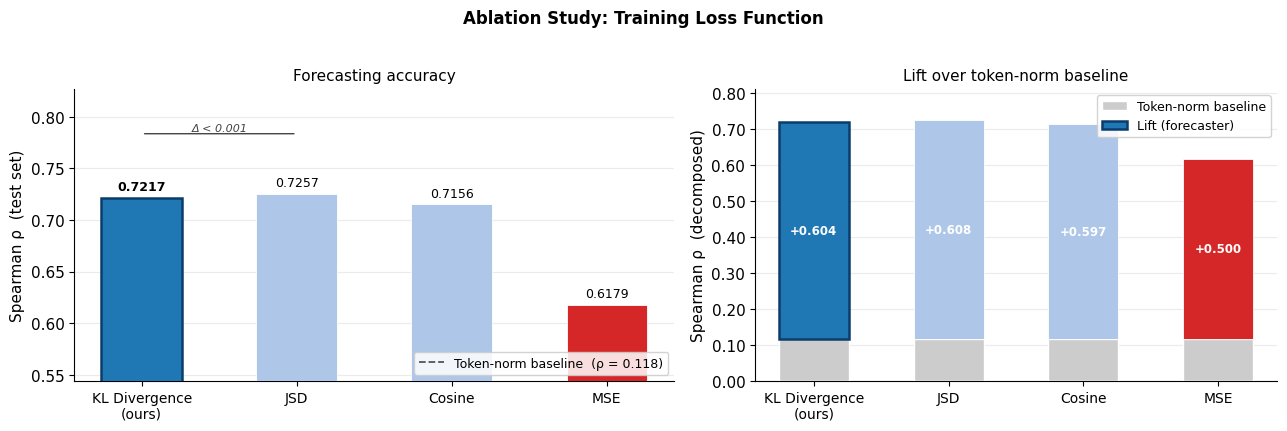

Saved → results/loss_ablation_NCT-CRC-HE_final.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

# ── load results (works even without re-running training) ─────────────────────
import pandas as pd
df_plot = pd.read_csv(f"results/loss_ablation_{dataset_name}.csv")

# Drop KL+MSE — paper uses KL only
df_plot = df_plot[df_plot["loss"] != "KL+MSE (paper)"].copy()

# Canonical display names & order
name_map = {
    "KL only":  "KL Divergence\n(ours)",
    "JSD":      "JSD",
    "Cosine":   "Cosine",
    "MSE only": "MSE",
}
df_plot["label"] = df_plot["loss"].map(name_map)
order = ["KL Divergence\n(ours)", "JSD", "Cosine", "MSE"]
# Map known aliases, but keep already-canonical names (e.g., "KL Divergence\n(ours)", "MSE")
df_plot["label"] = df_plot["loss"].map(name_map).fillna(df_plot["loss"])

# Reorder safely without KeyError if any label is missing
df_plot = (
    df_plot.dropna(subset=["label"])
           .set_index("label")
           .reindex(order)
           .dropna(how="all")
           .reset_index()
)

# ── style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

OURS_COLOR    = "#1f77b4"
OTHER_COLORS  = ["#aec7e8", "#aec7e8", "#d62728"]   # JSD, Cosine same grey-blue; MSE red (outlier)
BASELINE_COLOR = "#555555"
palette = [OURS_COLOR] + OTHER_COLORS

baseline_rho = df_plot["test_rho_token_norm"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
fig.suptitle("Ablation Study: Training Loss Function", fontsize=12, fontweight="bold", y=1.02)

labels = df_plot["label"].tolist()
x = np.arange(len(labels))
bar_w = 0.52

# ── LEFT: Spearman ρ on test set ──────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, df_plot["test_rho_forecaster"], width=bar_w, color=palette,
              edgecolor="white", linewidth=0.6, zorder=3)

# Highlight our method with a border
bars[0].set_edgecolor("#0a3d6b")
bars[0].set_linewidth(1.8)

# Baseline
ax.axhline(baseline_rho, color=BASELINE_COLOR, ls="--", lw=1.3, zorder=2,
           label=f"Token-norm baseline  (ρ = {baseline_rho:.3f})")

# Value labels
for bar, val in zip(bars, df_plot["test_rho_forecaster"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9,
            fontweight="bold" if bar == bars[0] else "normal")

# Bracket showing "ours is best among KL-based"
y_top = df_plot["test_rho_forecaster"].max() * 1.08
ours_x = bars[0].get_x() + bar_w / 2
jsd_x  = bars[1].get_x() + bar_w / 2
ax.annotate("", xy=(jsd_x, y_top), xytext=(ours_x, y_top),
            arrowprops=dict(arrowstyle="-", color="#444", lw=1.0))
ax.text((ours_x + jsd_x) / 2, y_top + 0.003, "Δ < 0.001", ha="center",
        fontsize=8, color="#444", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Spearman ρ  (test set)", fontsize=11)
ax.set_title("Forecasting accuracy", fontsize=11)
rho_min = df_plot["test_rho_forecaster"].min()
ax.set_ylim(rho_min * 0.88, df_plot["test_rho_forecaster"].max() * 1.14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(fontsize=9, framealpha=0.85, loc="lower right")
ax.grid(axis="y", alpha=0.25, zorder=0)

# ── RIGHT: stacked bar — baseline + lift ──────────────────────────────────────
ax2 = axes[1]
lift = df_plot["delta_rho"].values
base = np.full(len(labels), baseline_rho)

b1 = ax2.bar(x, base,  width=bar_w, color="#cccccc", label="Token-norm baseline",
             edgecolor="white", zorder=3)
b2 = ax2.bar(x, lift,  width=bar_w, color=palette, bottom=base,
             edgecolor="white", linewidth=0.6, label="Lift (forecaster)", zorder=3)
b2[0].set_edgecolor("#0a3d6b"); b2[0].set_linewidth(1.8)

# Lift labels inside the coloured segment
for i, (bar, lv) in enumerate(zip(b2, lift)):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             base[i] + lv / 2,
             f"+{lv:.3f}", ha="center", va="center", fontsize=8.5,
             color="white", fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel("Spearman ρ  (decomposed)", fontsize=11)
ax2.set_title("Lift over token-norm baseline", fontsize=11)
ax2.set_ylim(0, (base + lift).max() * 1.12)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax2.legend(fontsize=9, framealpha=0.85, loc="upper right")
ax2.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
out_path = f"results/loss_ablation_{dataset_name}_final.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


In [10]:
print("Risultati ablation loss:\n")
print(df[["loss", "test_rho_forecaster", "test_rho_token_norm",
          "delta_rho", "best_val_kl"]].to_string(index=False))

Risultati ablation loss:

                 loss  test_rho_forecaster  test_rho_token_norm  delta_rho  best_val_kl
           Reverse KL             0.729956              0.11809   0.611866    -0.342098
                  JSD             0.725675              0.11809   0.607585    -0.342005
              Pearson             0.722548              0.11809   0.604458    -0.337428
KL Divergence\n(ours)             0.721661              0.11809   0.603571    -0.341850
               Cosine             0.715565              0.11809   0.597475    -0.341631
             L1 / MAE             0.637336              0.11809   0.519246    -0.333595
                  MSE             0.617878              0.11809   0.499788    -0.327507
                Huber             0.603579              0.11809   0.485489    -0.326857
